In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'your_username'
os.environ['KAGGLE_KEY'] = 'your_key'

In [ ]:
!pip install kaggle

In [ ]:
import kaggle
print("Kaggle installed correctly")

Kaggle installed correctly


In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    "asifxzaman/social-media-addiction-vs-productivity-dataset",
    path="./data",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/asifxzaman/social-media-addiction-vs-productivity-dataset


In [ ]:
import pandas as pd

df = pd.read_csv("./data/social_media_productivity_6000.csv")
df.head()


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [ ]:
df.describe()


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,58.560000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,100.000000


Darrah ***

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For statistical testing
from scipy.stats import ttest_ind

# For regression
import statsmodels.api as sm

# Display settings
pd.set_option('display.max_columns', None)

print("Setup complete.")

Setup complete.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving social_media_clean.csv to social_media_clean.csv


In [ ]:
df = pd.read_csv("social_media_clean.csv")
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score,addiction_encoded,social_media_ratio
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49,1,0.472269
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54,1,0.609948
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52,0,0.459384
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82,1,0.425511
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09,0,0.661157


In [ ]:
# Structure
df.info()

# Summary stats
df.describe()

# Missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5971 entries, 0 to 5970
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5971 non-null   float64
 1   daily_screen_time      5971 non-null   float64
 2   social_media_hours     5971 non-null   float64
 3   study_hours            5971 non-null   float64
 4   sleep_hours            5971 non-null   float64
 5   notifications_per_day  5971 non-null   float64
 6   focus_score            5971 non-null   float64
 7   addiction_level        5971 non-null   object 
 8   productivity_score     5971 non-null   float64
 9   addiction_encoded      5971 non-null   int64  
 10  social_media_ratio     5971 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 513.3+ KB


,0
age,0
daily_screen_time,0
social_media_hours,0
study_hours,0
sleep_hours,0
notifications_per_day,0
focus_score,0
addiction_level,0
productivity_score,0
addiction_encoded,0


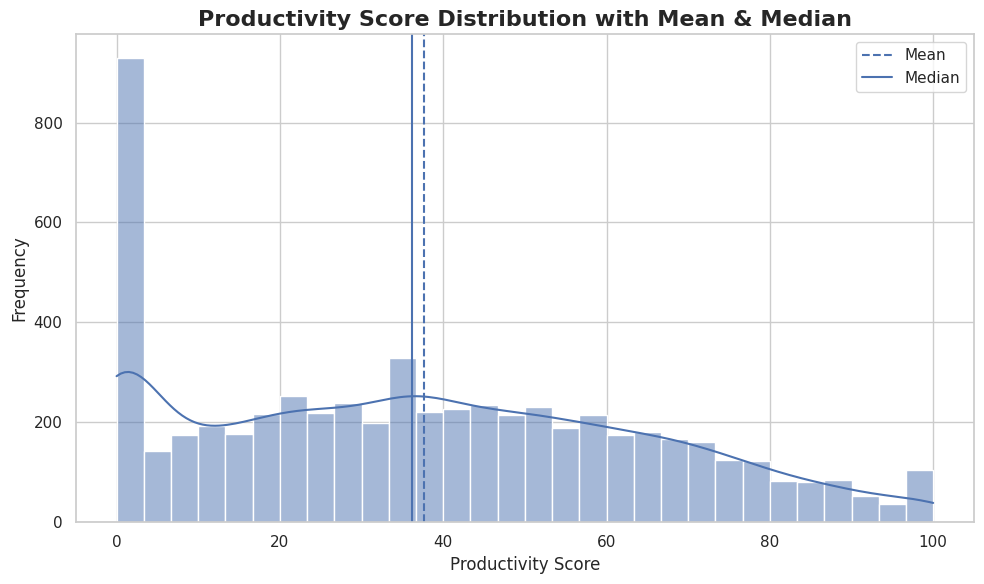

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['productivity_score'],
    bins=30,
    kde=True
)

plt.axvline(df['productivity_score'].mean(), linestyle='--', label='Mean')
plt.axvline(df['productivity_score'].median(), linestyle='-', label='Median')

plt.title("Productivity Score Distribution with Mean & Median", fontsize=16, weight='bold')
plt.xlabel("Productivity Score")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()

**Distribution of Productivity Score**

The distribution of the productivity score reveals a wide spread of values across the population, with a noticeable concentration of observations at the lower end of the scale.

A visible cluster of near-zero productivity scores suggests the presence of a subgroup of individuals with extremely low productivity levels, which aligns with behavioral patterns such as high social media usage and low study time observed in the dataset.

Overall, the distribution does not follow a perfectly normal shape and appears slightly skewed, indicating variability in user behavior and productivity outcomes.

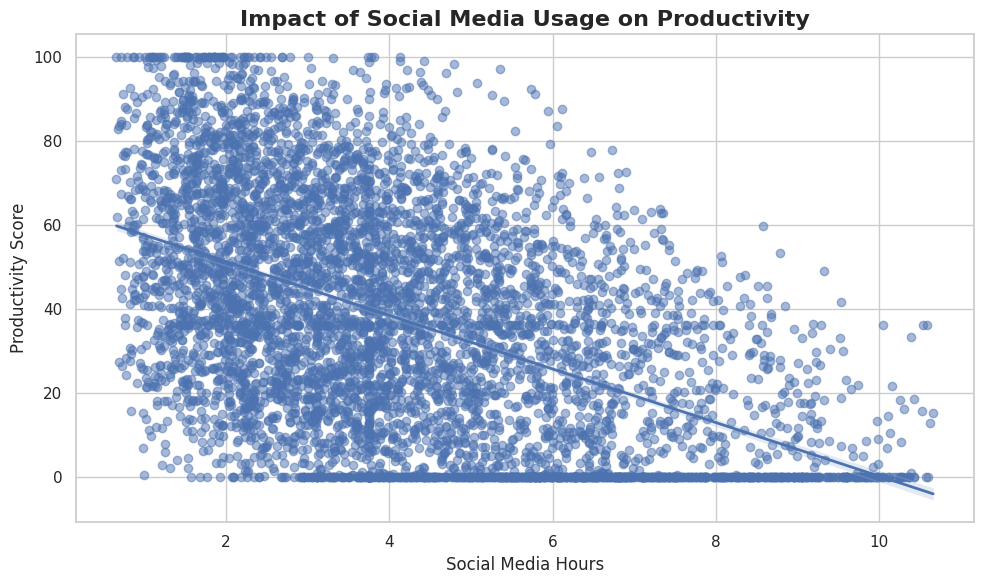

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='social_media_hours',
    y='productivity_score',
    scatter_kws={'alpha': 0.5},
    line_kws={'linewidth': 2}
)

plt.title("Impact of Social Media Usage on Productivity", fontsize=16, weight='bold')
plt.xlabel("Social Media Hours")
plt.ylabel("Productivity Score")

plt.tight_layout()
plt.show()

**Social Media Usage vs Productivity**

The scatterplot between social media hours and productivity score shows a clear negative relationship.

As social media usage increases, productivity tends to decrease. While there is some dispersion in the data, the overall trend indicates that individuals who spend more time on social media are more likely to have lower productivity scores.

This pattern suggests that excessive social media engagement may act as a distraction factor, reducing time and focus allocated to productive activities.

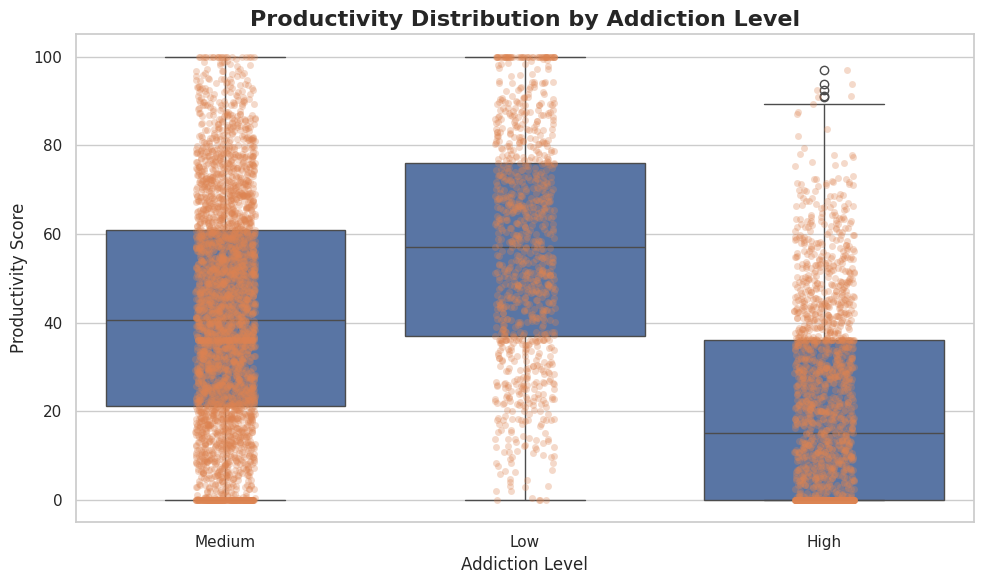

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='addiction_level',
    y='productivity_score'
)

sns.stripplot(
    data=df,
    x='addiction_level',
    y='productivity_score',
    alpha=0.3
)

plt.title("Productivity Distribution by Addiction Level", fontsize=16, weight='bold')
plt.xlabel("Addiction Level")
plt.ylabel("Productivity Score")

plt.tight_layout()
plt.show()

**Productivity by Addiction Level**

The boxplot comparing productivity across addiction levels highlights a strong downward trend.

- Individuals with low addiction exhibit higher median productivity scores
- Those with medium addiction show a moderate decline
- Individuals with high addiction demonstrate the lowest productivity levels, along with greater variability

This indicates that addiction level is a key differentiating factor in productivity outcomes.

# **HYPOTHESIS TEST (T-TEST)**

In [ ]:
low_sm = df[df['social_media_hours'] < 3]['productivity_score']
high_sm = df[df['social_media_hours'] >= 3]['productivity_score']

In [ ]:
t_stat, p_val = ttest_ind(low_sm, high_sm)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 32.87920522381882
P-value: 4.686414808356325e-218


This tells us that there is a real and significant difference in productivity between people who spend less time on social media and those who spend more.

In simple terms, it’s not just random — social media usage actually has a measurable impact on productivity.

# This actually matches what I saw earlier in the EDA — when social media usage goes up, productivity clearly goes down.

So now it’s not just something I’m observing visually, it’s backed by actual statistical evidence.

# **REGRESSION MODEL** ( I )

In [ ]:
# Select features
X = df[['social_media_hours', 'study_hours', 'sleep_hours',
        'focus_score', 'notifications_per_day']]

y = df['productivity_score']

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_score   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     6140.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:25:06   Log-Likelihood:                -22798.
No. Observations:                5971   AIC:                         4.561e+04
Df Residuals:                    5965   BIC:                         4.565e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    60.72

# Regression was used because the target variable, productivity_score, is continuous. This allows us to predict exact values and quantify how each factor (e.g., social media usage, study time, focus) impacts productivity.

# It also provides interpretable coefficients, making it possible to understand the direction and magnitude of each variable’s effect, which is essential for both analysis and decision-making.

# **Test**

In [ ]:
df['productivity_class'] = pd.qcut(
    df['productivity_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df[['productivity_score', 'productivity_class']].head()

,productivity_score,productivity_class
0,28.49,Medium
1,18.54,Low
2,68.52,High
3,27.82,Medium
4,51.09,High


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['addiction_encoded'] = le.fit_transform(df['addiction_level'])
df['productivity_class_encoded'] = le.fit_transform(df['productivity_class'])

In [ ]:
features = [
    'social_media_hours',
    'study_hours',
    'sleep_hours',
    'focus_score',
    'notifications_per_day',
    'addiction_encoded'
]

X = df[features]

# Targets
y_reg = df['productivity_score']  # regression
y_clf = df['productivity_class_encoded']  # classification

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_reg)

y_pred_rf = rf.predict(X_test)

# TRAIN / TEST SPLIT

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train_reg)

y_pred_lr = lr.predict(X_test)

# MODEL 1 (LINEAR REGRESSION)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_reg)

y_pred_rf = rf.predict(X_test)

# MODEL 2 (RANDOM FOREST )

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train_clf)

y_pred_clf = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print(classification_report(y_test_clf, y_pred_clf))

# MODEL 3 (CLASSIFICATION )

Accuracy: 0.8050209205020921
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       388
           1       0.86      0.87      0.86       394
           2       0.72      0.71      0.72       413

    accuracy                           0.81      1195
   macro avg       0.81      0.81      0.81      1195
weighted avg       0.80      0.81      0.80      1195



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression R2:", r2_score(y_test_reg, y_pred_lr))
print("Random Forest R2:", r2_score(y_test_reg, y_pred_rf))

# EVALUATION

Linear Regression R2: 0.8181512761847172
Random Forest R2: 0.8275654566043549


In [ ]:
importance = rf.feature_importances_

feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feat_importance

,Feature,Importance
3,focus_score,0.422199
1,study_hours,0.329951
0,social_media_hours,0.140584
2,sleep_hours,0.067563
4,notifications_per_day,0.033518
5,addiction_encoded,0.006186


# I didn’t rely on a single model. I compared linear regression with ensemble methods like Random Forest and also reframed the problem as a classification task to better capture behavioral patterns.

In [ ]:
coeffs = model.params

for var in coeffs.index:
    print(f"{var}: {coeffs[var]:.2f}")

const: 60.72
social_media_hours: -7.57
study_hours: 9.37
sleep_hours: 4.73
focus_score: -0.57
notifications_per_day: -0.03


# Final Regression Analysis

The regression results provide clear insights into how behavioral factors influence productivity.

The intercept (60.72) represents the baseline productivity score when all predictors are held constant. Among all variables, study_hours has the strongest positive impact, where each additional hour of study increases productivity by approximately 9.37 points, highlighting it as the most influential factor.

In contrast, social_media_hours shows a strong negative effect. Each additional hour spent on social media reduces productivity by about 7.57 points, indicating that excessive usage significantly hinders performance.

Other variables also contribute meaningfully:

- sleep_hours (+4.73) suggests that adequate rest improves productivity
- focus_score (-0.57) shows a slight negative relationship, which may indicate underlying data complexity or multicollinearity
- notifications_per_day (-0.03) has a minimal but negative effect, suggesting that frequent interruptions slightly reduce productivity

Overall, productivity is primarily driven by time allocation and behavioral habits. Activities that promote focus and effort (such as studying and sleeping) increase productivity, while distractions (such as social media and notifications) reduce it.

****

From the EDA, I observed a negative relationship between social media usage and productivity.
The hypothesis test confirmed that this relationship is statistically significant.
The regression model further quantified this effect, showing that each additional hour of social media reduces productivity.

- Productivity is driven by behavioral habits
- Study time = strongest positive driver
- Social media = strongest negative driver
- Sleep = important supporting factor
- Notifications = small but real distraction

Based on the analysis, productivity can be improved by increasing focused study time and reducing social media usage. Additionally, maintaining healthy sleep patterns and minimizing digital interruptions can further enhance performance.